In [2]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes,add_disinfo_nodes
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing
import numpy as np
import matplotlib.pyplot as plt

In [3]:
TestGraf =  ws_opinion_graph(10000,150,0.1,seed = 11)

MatrixGraf = create_matrix_rep(TestGraf)
mask = MatrixGraf.type == 'Human'


In [4]:
Del_et_tidskridt  = 100
Del_to_tidskridt = 100
Del_tre_tidskridt = 100

In [5]:
MatrixGraf.opinions, no_media_no_disinfo_sim_results,no_media_no_disinfo_startcond,no_media_no_disinfo_endcond= simpel_simulering(MatrixGraf,Del_et_tidskridt)
average_opinionresult, average_distance_to_the_mean_result = data_processing(no_media_no_disinfo_sim_results,mask)


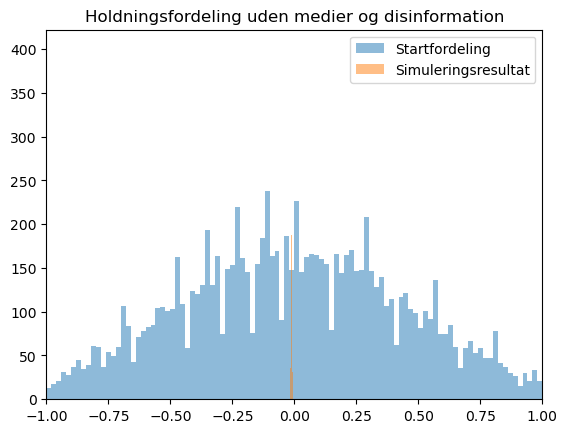

In [6]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond[mask], bins=100, alpha=0.5, label='Startfordeling')
plt.hist(no_media_no_disinfo_endcond[mask], bins=100, alpha=0.5, label='Simuleringsresultat')
plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling uden medier og disinformation')
plt.show()


In [7]:
MatrixGrafMedia=add_media_nodes(MatrixGraf,300,0.2,seed =11)
maskmedia = MatrixGrafMedia.type == 'Human'
MatrixGrafMedia.opinions, media_no_disinfo_sim_results,media_no_disinfo_startcond,media_no_disinfo_endcond= simpel_simulering(MatrixGrafMedia,Del_to_tidskridt)
media_average_opinionresult, media_average_distance_to_the_mean_result = data_processing(media_no_disinfo_sim_results,maskmedia)


In [9]:
print('Max = ',max(no_media_no_disinfo_endcond))
print('Min = ',min(no_media_no_disinfo_endcond))
print('|Diff| = ', abs(max(no_media_no_disinfo_endcond)-min(no_media_no_disinfo_endcond)))

Max =  -0.006824904246534779
Min =  -0.01673485276329105
|Diff| =  0.009909948516756271


In [18]:
#print(MatrixGrafMedia.opinions[MatrixGrafMedia.type == 'Media'])


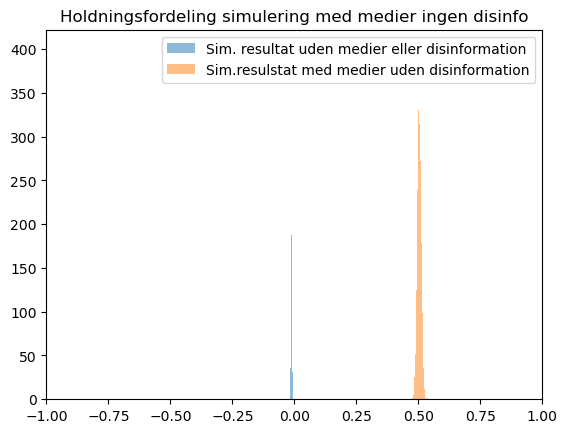

In [11]:
plt.figure()
plt.hist(media_no_disinfo_startcond[maskmedia], bins=100, alpha=0.5, label='Sim. resultat uden medier eller disinformation')
plt.hist(media_no_disinfo_endcond[maskmedia], bins=100, alpha=0.5, label='Sim.resulstat med medier uden disinformation')
plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling simulering med medier ingen disinfo')
plt.show()

In [12]:
MatrixGrafdisinfo=add_disinfo_nodes(MatrixGrafMedia,300,0.2,seed =11)
maskdisinfo = MatrixGrafdisinfo.type == 'Human'
MatrixGrafdisinfo.opinions, media_disinfo_sim_results,media_disinfo_startcond,media_disinfo_endcond= simpel_simulering(MatrixGrafdisinfo,Del_tre_tidskridt)
media_disinfo_average_opinionresult, media_disinfo_average_distance_to_the_mean_result = data_processing(media_disinfo_sim_results,maskdisinfo)


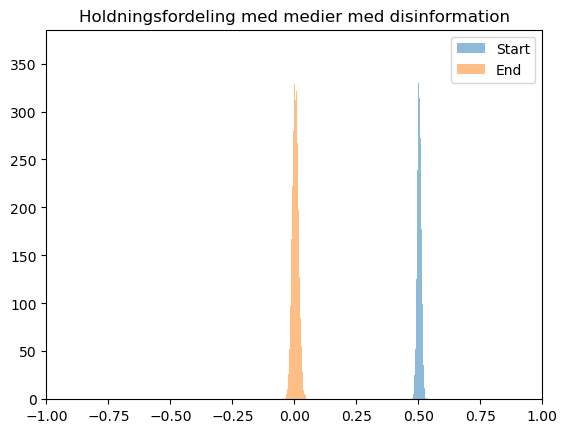

In [13]:
plt.figure()
plt.hist(media_disinfo_startcond[maskdisinfo], bins=100, alpha=0.5, label='Start')
plt.hist(media_disinfo_endcond[maskdisinfo], bins=100, alpha=0.5, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling med medier med disinformation')
plt.show()


In [14]:

totalgennemsnit = np.concatenate((average_opinionresult,media_average_opinionresult,media_disinfo_average_opinionresult))

totalgennemgennemsnit = np.concatenate((average_distance_to_the_mean_result,media_average_distance_to_the_mean_result,media_disinfo_average_distance_to_the_mean_result))


0.5042000000000001
-0.49579999999999996


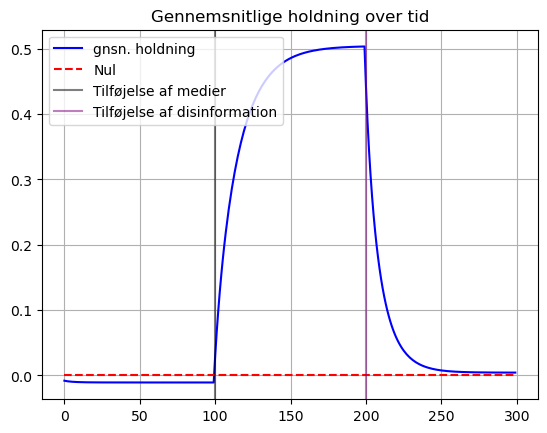

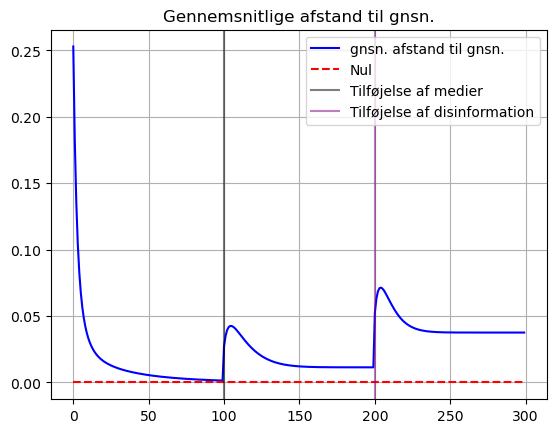

In [20]:
#print(MatrixGrafdisinfo.opinions[MatrixGrafdisinfo.type == 'Media'])
print(MatrixGrafdisinfo.opinions[MatrixGrafdisinfo.type == 'Media'].mean())

#print(MatrixGrafdisinfo.opinions[MatrixGrafdisinfo.type == 'Disinformation'])
print(MatrixGrafdisinfo.opinions[MatrixGrafdisinfo.type == 'Disinformation'].mean())

plt.figure()
plt.plot(np.arange(len(totalgennemsnit)),totalgennemsnit,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(totalgennemsnit)),np.zeros(len(totalgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt,color = 'k', alpha=0.5, label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5, label = 'Tilføjelse af disinformation')

plt.legend(loc = 'upper left')
plt.grid()
plt.title('Gennemsnitlige holdning over tid')
plt.show()

plt.figure()
plt.plot(np.arange(len(totalgennemgennemsnit)),totalgennemgennemsnit,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(totalgennemgennemsnit)),np.zeros(len(totalgennemgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt, color = 'k',alpha=0.5,label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5,label = 'Tilføjelse af disinformation')

plt.legend()
plt.grid()
plt.title('Gennemsnitlige afstand til gnsn.')
plt.show()

np.float64(0.0006275102781447383)

In [16]:
MatrixGrafdisinfo.type

array(['Human', 'Human', 'Human', ..., 'Disinformation', 'Disinformation',
       'Disinformation'], shape=(10600,), dtype='<U14')

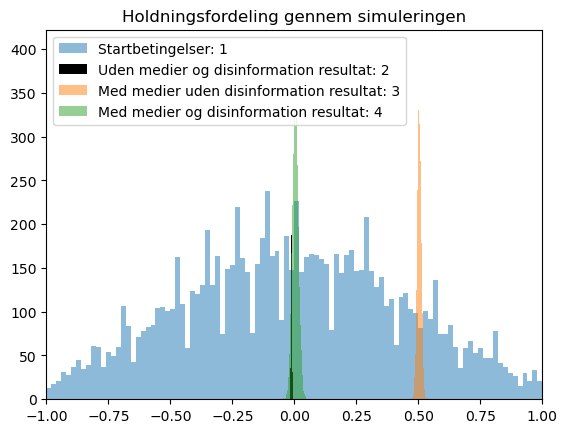

In [17]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond[mask], bins=100, alpha=0.5, label='Startbetingelser: 1')
plt.hist(no_media_no_disinfo_endcond[mask], bins=100,color ='k', alpha=1, label='Uden medier og disinformation resultat: 2')
plt.hist(media_no_disinfo_endcond[maskmedia], bins=100, alpha=0.5, label='Med medier uden disinformation resultat: 3')
plt.hist(media_disinfo_endcond[maskdisinfo], bins=100, alpha=0.5, label='Med medier og disinformation resultat: 4')


plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling gennem simuleringen')
plt.show()
